STUDENT PERFORMANCE INDICATER

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('data\stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [8]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
print("Categories in 'gender' variable: ",end="")
print(df['gender'].unique())
print("Categories in 'race_ethnicity' variable: ",end="")
print(df['race_ethnicity'].unique())
print("Categories in 'parental_level_of_education' variable: ",end="")
print(df['parental_level_of_education'].unique())
print("Categories in 'lunch' variable: ",end="")
print(df['lunch'].unique())
print("Categories in 'test_preparation_course' variable: ",end="")
print(df['test_preparation_course'].unique())


Categories in 'gender' variable: ['female' 'male']
Categories in 'race_ethnicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test_preparation_course' variable: ['none' 'completed']


In [11]:
numeric_features=[feature for feature in df.columns if df[feature].dtype!='O']
categorical_features=[feature for feature in df.columns if df[feature].dtype=='O']
print('we have {} numerical features: {}'.format(len(numeric_features),numeric_features))
print('\nwe have {} categorical features: {}'.format(len(categorical_features),categorical_features))

we have 3 numerical features: ['math_score', 'reading_score', 'writing_score']

we have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [12]:
df['total']=df['math_score']+df['reading_score']+df['writing_score']
df['average']=df['total']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
reading_full=df[df['reading_score']==100]['average'].count()
writing_full=df[df['writing_score']==100]['average'].count()
math_full=df[df['math_score']==100]['average'].count()

print(f"nummber of students  with full marks in math: {math_full}")
print(f"nummber of students  with full marks in reading: {reading_full}")
print(f"nummber of students  with full marks in writinig : {writing_full}")

nummber of students  with full marks in math: 7
nummber of students  with full marks in reading: 17
nummber of students  with full marks in writinig : 14


In [14]:
reading_less_20=df[df['reading_score']<=20]['average'].count()
writing_less_20=df[df['writing_score']<=20]['average'].count()
math_less_20=df[df['math_score']<=20]['average'].count()

print(f"nummber of students  with less 20  marks in math: {math_less_20}")
print(f"nummber of students  with less 20 marks in reading: {reading_less_20}")
print(f"nummber of students  with less 20 marks in writinig : {writing_less_20}")

nummber of students  with less 20  marks in math: 4
nummber of students  with less 20 marks in reading: 1
nummber of students  with less 20 marks in writinig : 3


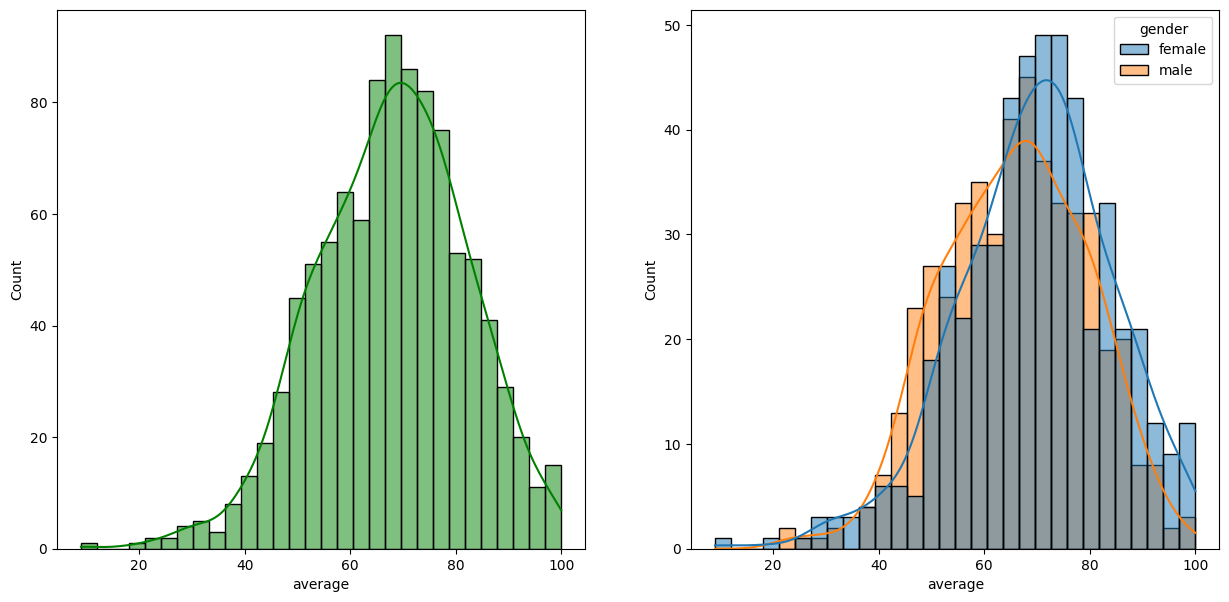

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=df, x='average', bins=30, kde=True, color='r',hue='gender')

plt.show()

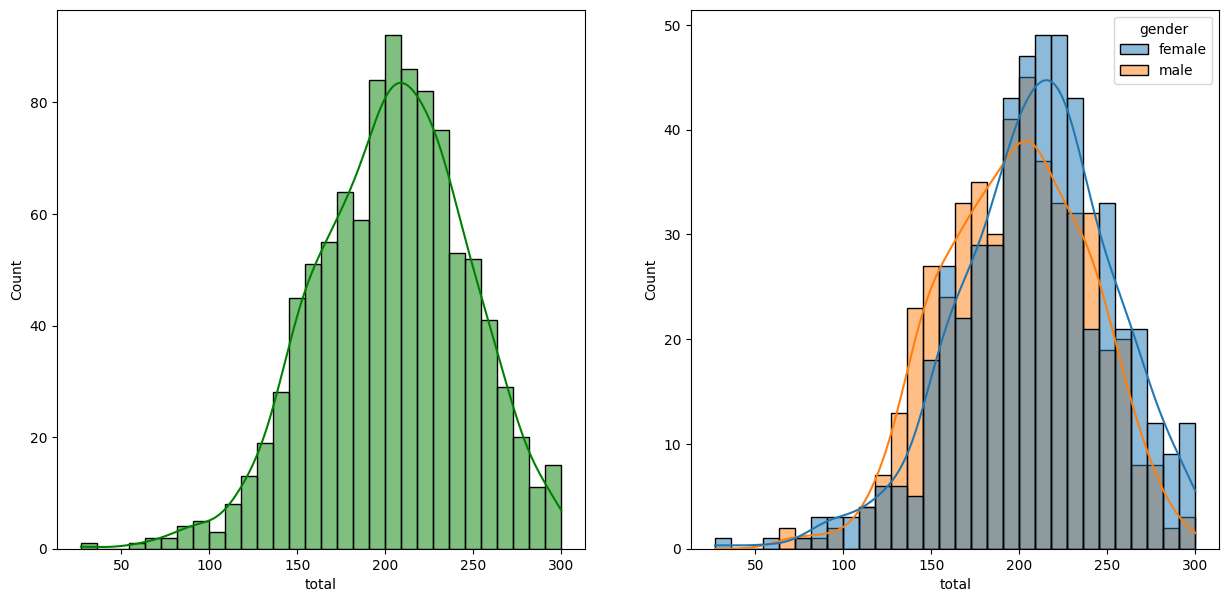

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df, x='total', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=df, x='total', bins=30, kde=True, color='r',hue='gender')

plt.show()

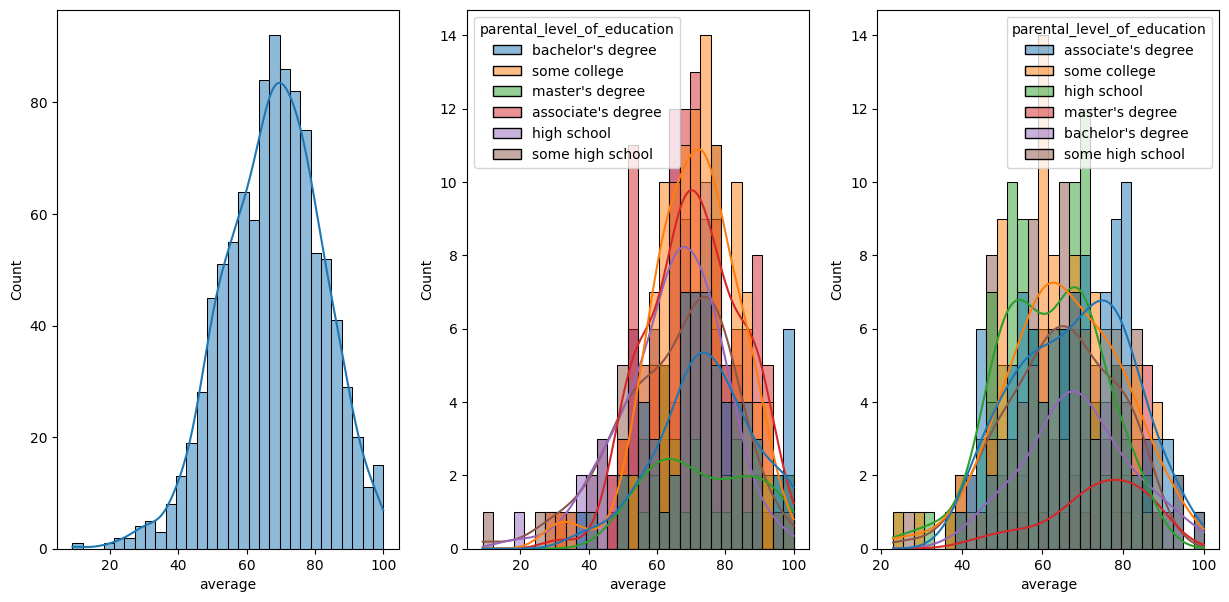

In [17]:
plt.figure(figsize=(15,7))

plt.subplot(131)
sns.histplot(data=df, x='average', bins=30, kde=True)

plt.subplot(132)
sns.histplot(data=df[df.gender=='female'], x='average', bins=30, kde=True, hue='parental_level_of_education')

plt.subplot(133)
sns.histplot(data=df[df.gender=='male'], x='average', bins=30, kde=True, hue='parental_level_of_education')

plt.show()

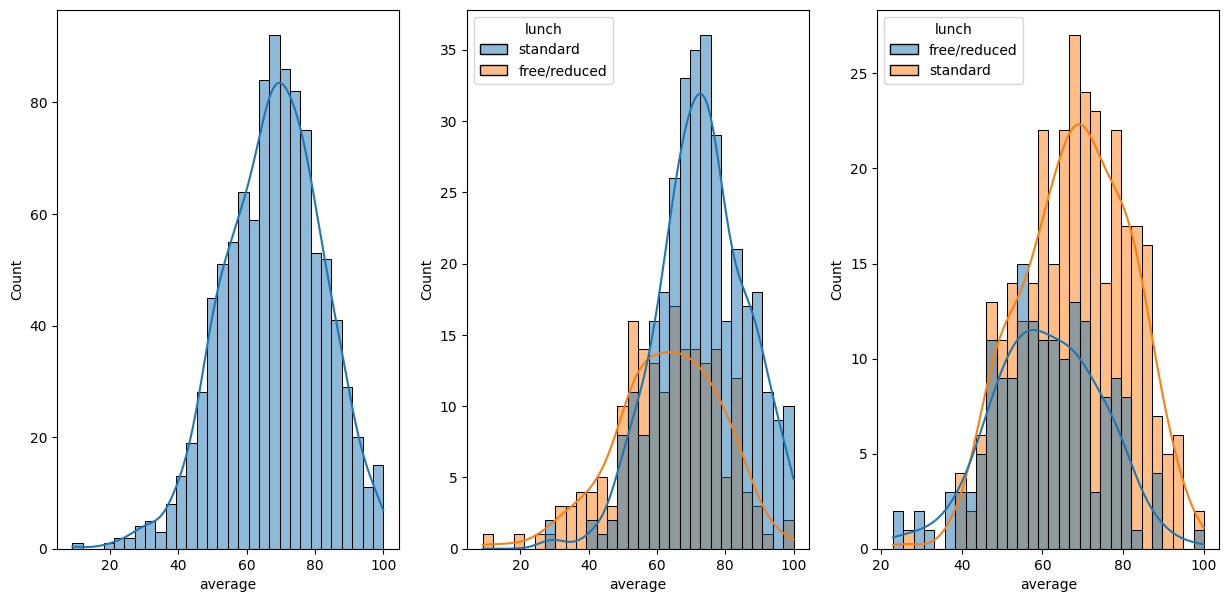

In [18]:
plt.figure(figsize=(15,7))

plt.subplot(131)
sns.histplot(data=df, x='average', bins=30, kde=True)

plt.subplot(132)
sns.histplot(data=df[df.gender=='female'], x='average', bins=30, kde=True, hue='lunch')

plt.subplot(133)
sns.histplot(data=df[df.gender=='male'], x='average', bins=30, kde=True, hue='lunch')

plt.show()

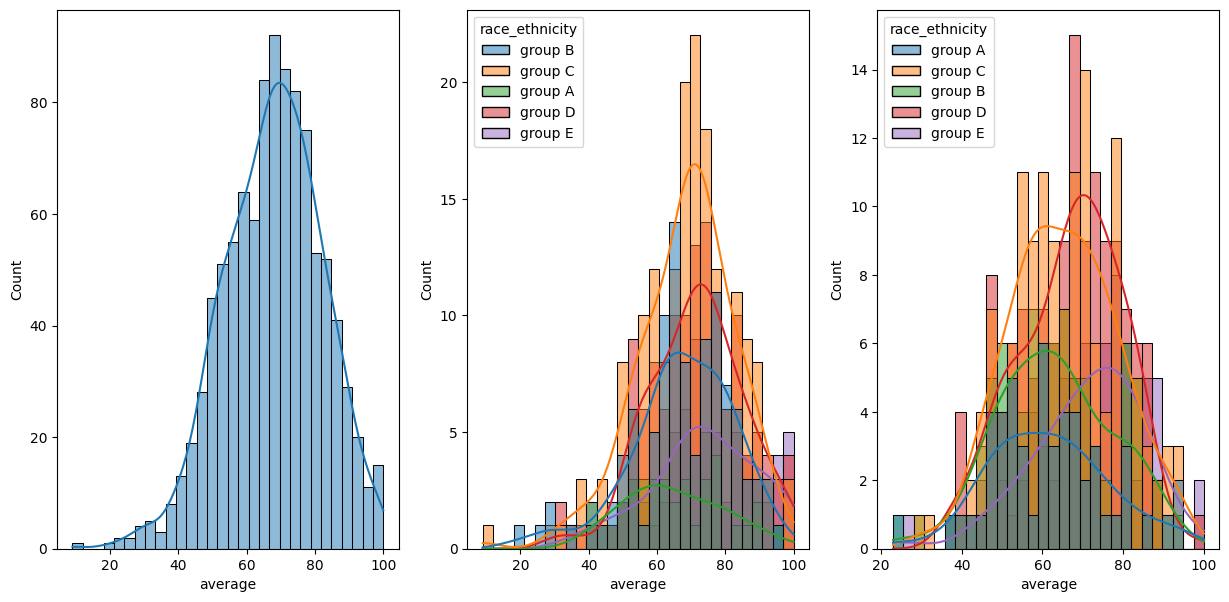

In [19]:
plt.figure(figsize=(15,7))

plt.subplot(131)
sns.histplot(data=df, x='average', bins=30, kde=True)

plt.subplot(132)
sns.histplot(data=df[df.gender=='female'], x='average', bins=30, kde=True, hue='race_ethnicity')

plt.subplot(133)
sns.histplot(data=df[df.gender=='male'], x='average', bins=30, kde=True, hue='race_ethnicity')

plt.show()

In [20]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


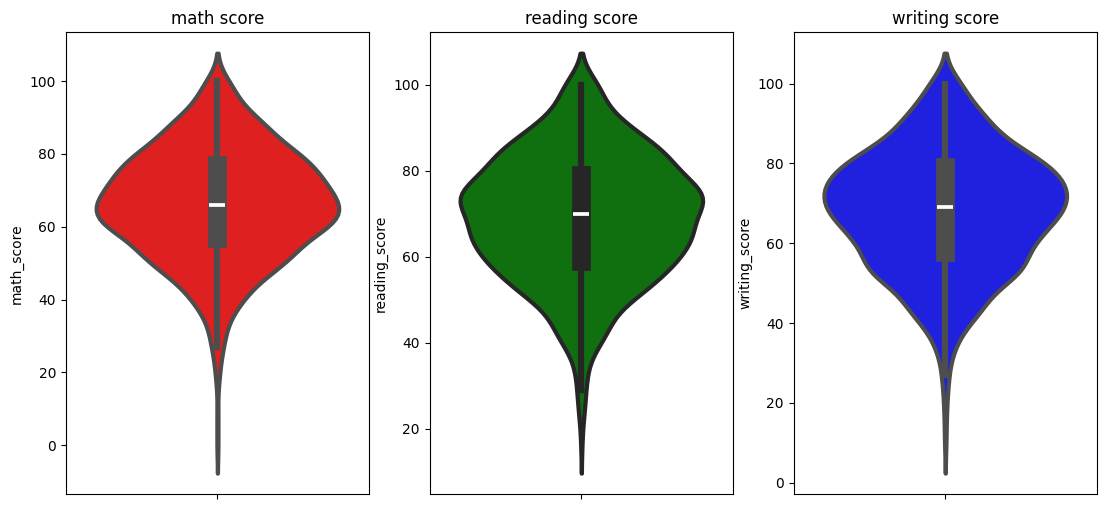

In [21]:
plt.figure(figsize=(18,6))

plt.subplot(1,4,1)
plt.title('math score')
sns.violinplot(y='math_score', data=df, color='red', linewidth=3)

plt.subplot(1,4,2)
plt.title('reading score')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3)

plt.subplot(1,4,3)
plt.title('writing score')
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3)

plt.show()

In [22]:
df['test_preparation_course'].unique()

array(['none', 'completed'], dtype=object)

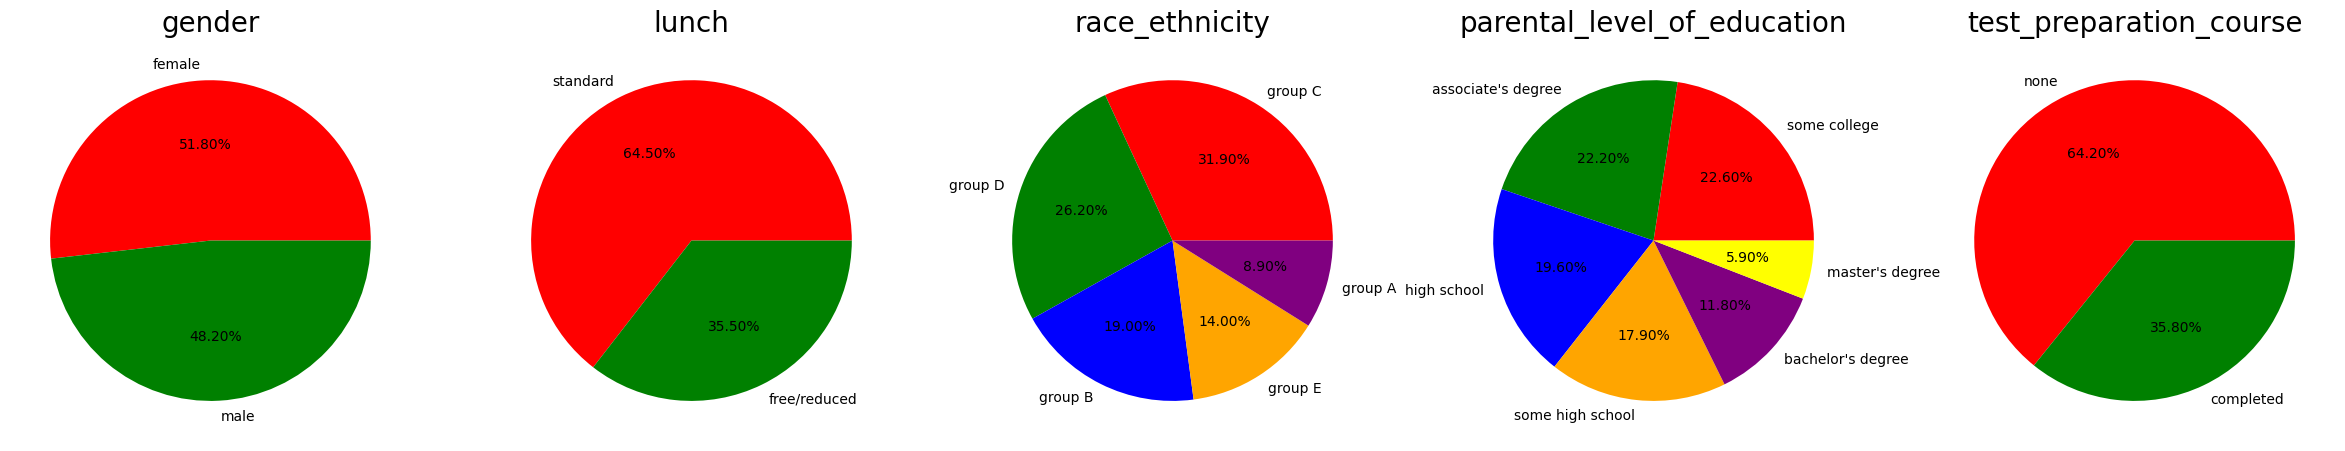

In [23]:
plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(1,5,1)
size = df['gender'].value_counts()
plt.pie(size, labels=size.index, colors=['red','green'], autopct='%.2f%%')
plt.title('gender', fontsize=20)
plt.axis('off')


plt.subplot(1,5,2)
size = df['lunch'].value_counts()
plt.pie(size, labels=size.index, colors=['red','green'], autopct='%.2f%%')
plt.title('lunch', fontsize=20)
plt.axis('off')


plt.subplot(1,5,3)
size = df['race_ethnicity'].value_counts()
plt.pie(size, labels=size.index, colors=['red','green','blue','orange','purple'], autopct='%.2f%%')
plt.title('race_ethnicity', fontsize=20)
plt.axis('off')


plt.subplot(1,5,4)
size = df['parental_level_of_education'].value_counts()
plt.pie(size, labels=size.index, colors=['red','green','blue','orange','purple','yellow'], autopct='%.2f%%')
plt.title('parental_level_of_education', fontsize=20)
plt.axis('off')


plt.subplot(1,5,5)
size = df['test_preparation_course'].value_counts()
plt.pie(size, labels=size.index, colors=['red','green'], autopct='%.2f%%')
plt.title('test_preparation_course', fontsize=20)
plt.axis('off')

plt.show()

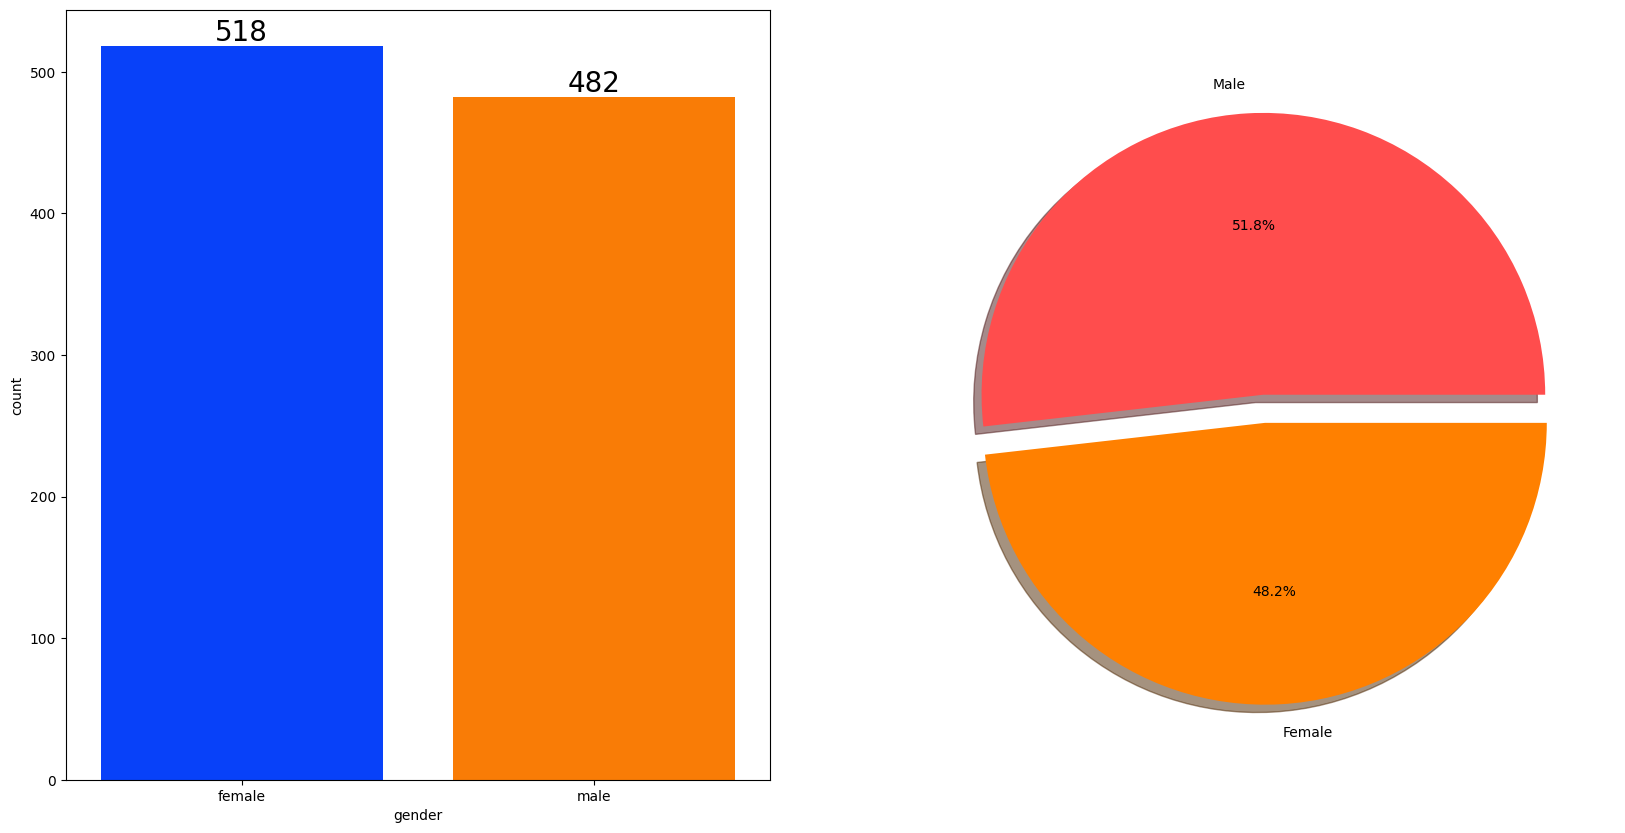

In [24]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

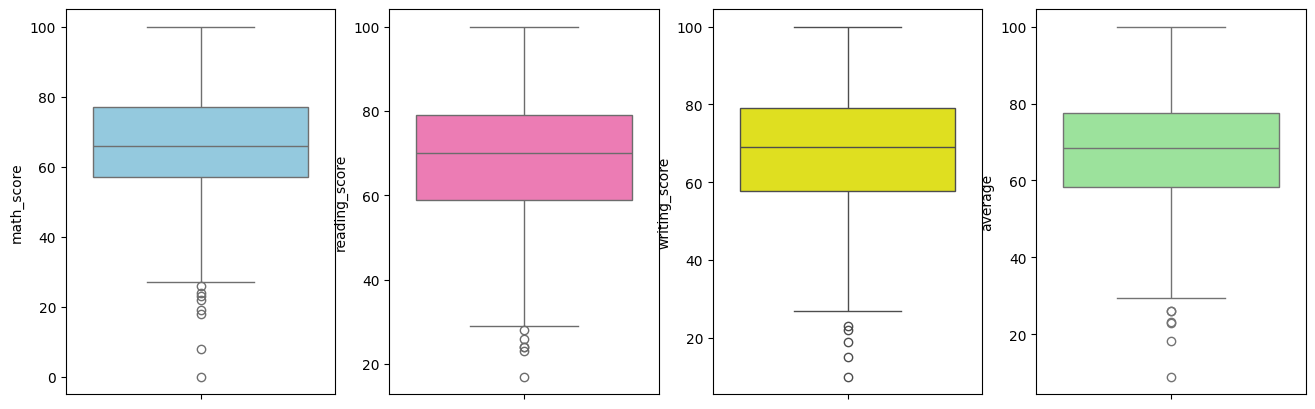

In [26]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

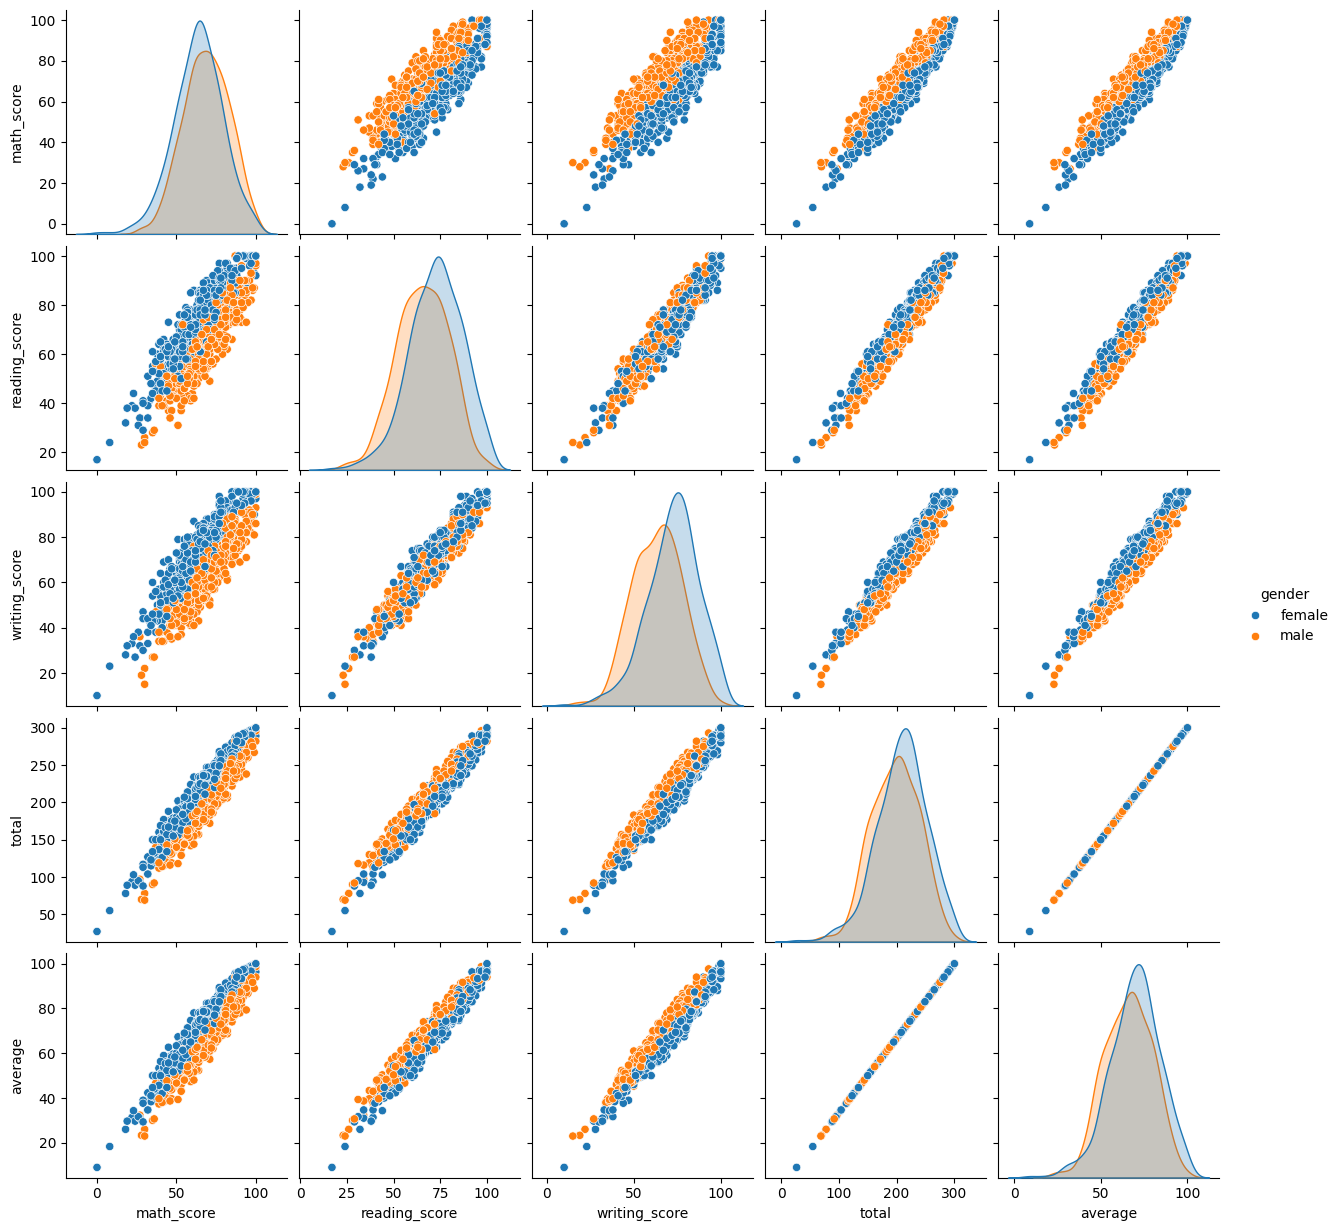

In [27]:
sns.pairplot(df,hue = 'gender')
plt.show()